In [1]:
# Importing req librariers

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Importing data
df = pd.read_csv('/content/qoute_dataset.csv')
df.head()

,quote,Author
0,“The world as we have created it is a process ...,Albert Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling
2,“There are only two ways to live your life. On...,Albert Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Creating tokenizer object and using it to generate unique tokens for each word

tokenizer = Tokenizer(num_words=4000)
tokenizer.fit_on_texts(df['quote'].to_list())
tokenizer.word_index

{'the': 1,
 'you': 2,
 'to': 3,
 'and': 4,
 'a': 5,
 'i': 6,
 'is': 7,
 'of': 8,
 'that': 9,
 'it': 10,
 'in': 11,
 'be': 12,
 'not': 13,
 'are': 14,
 'your': 15,
 'but': 16,
 'have': 17,
 'for': 18,
 'we': 19,
 'if': 20,
 'what': 21,
 'all': 22,
 'with': 23,
 'love': 24,
 'can': 25,
 'my': 26,
 'when': 27,
 'will': 28,
 'me': 29,
 'as': 30,
 'who': 31,
 'do': 32,
 'or': 33,
 'he': 34,
 'they': 35,
 'one': 36,
 'life': 37,
 'was': 38,
 'like': 39,
 'there': 40,
 'so': 41,
 'people': 42,
 'on': 43,
 'at': 44,
 'no': 45,
 'never': 46,
 "don't": 47,
 'them': 48,
 'know': 49,
 'just': 50,
 'more': 51,
 'because': 52,
 'only': 53,
 'this': 54,
 'than': 55,
 "it's": 56,
 'up': 57,
 'want': 58,
 'his': 59,
 'how': 60,
 'world': 61,
 'things': 62,
 'by': 63,
 'think': 64,
 'make': 65,
 'about': 66,
 'time': 67,
 'said': 68,
 'from': 69,
 'always': 70,
 'our': 71,
 'out': 72,
 'an': 73,
 'good': 74,
 'us': 75,
 'she': 76,
 'her': 77,
 'way': 78,
 'go': 79,
 'live': 80,
 'something': 81,
 'has':

In [6]:
# Creating sequence using the tokenizer
tokenized_sentence =  tokenizer.texts_to_sequences(df['quote'].to_list())

In [7]:
# Input sequence createion

input_sequences = [
    token_list[:i+1]
    for token_list in tokenized_sentence
    for i in range(1, len(token_list))
]

In [8]:
# Padding to make each se of equal size

max_len = 51
padded_input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

In [9]:
# Input array sample

padded_input_sequences

array([[   0,    0,    0, ...,    0,  732,   61],
       [   0,    0,    0, ...,  732,   61,   30],
       [   0,    0,    0, ...,   61,   30,   19],
       ...,
       [   0,    0,    0, ...,   19, 1333,    3],
       [   0,    0,    0, ..., 1333,    3,  174],
       [   0,    0,    0, ...,    3,  174,  104]], dtype=int32)

In [10]:
# Target and independent col
X = padded_input_sequences[:,:-1]
y = padded_input_sequences[:,-1]

In [11]:
# Input and target data shape

X.shape, y.shape

((82337, 50), (82337,))

## Model Building

In [12]:
# Model building
vocab_size = len(tokenizer.word_index) + 1

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100))
model.add(LSTM(64, dropout=0.4))
model.add(Dense(vocab_size, activation='softmax'))

In [13]:
# Complie

model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [14]:
# Model summary

model.build(input_shape=(None, max_len-1))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       821,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8214)           │       533,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,397,550 (5.33 MB)

 Trainable params: 1,397,550 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Fitting the model
early = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=5,              # stop if no improvement for 2 epochs
    restore_best_weights=True, # load best model automatically
    verbose=1
)

history = model.fit(
    X, y,
    epochs=100,
    batch_size=64,
    callbacks=[early],
    validation_split=0.1
)

Epoch 1/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.0390 - loss: 6.7066 - val_accuracy: 0.0418 - val_loss: 6.2121
Epoch 2/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.0514 - loss: 6.0321 - val_accuracy: 0.0661 - val_loss: 6.0041
Epoch 3/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.0754 - loss: 5.7865 - val_accuracy: 0.0896 - val_loss: 5.8955
Epoch 4/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.0984 - loss: 5.6183 - val_accuracy: 0.1015 - val_loss: 5.8165
Epoch 5/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1110 - loss: 5.4458 - val_accuracy: 0.1085 - val_loss: 5.7676
Epoch 6/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.1179 - loss: 5.3342 - val_accuracy: 0.1089 - val_loss: 5.7454
Epoch 7/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1265 - loss: 5.1975 - val_accuracy: 0.1140 - val_loss: 5.7399
Epoch 8/100
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1340

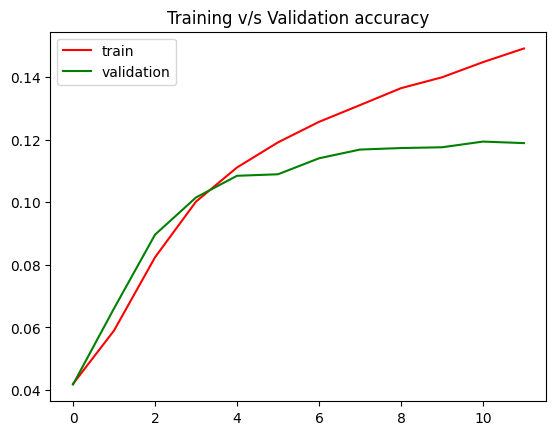

In [16]:
# Plotting training v/s validation accuracy

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'green', label = 'validation')
plt.title('Training v/s Validation accuracy')
plt.legend()
plt.show()

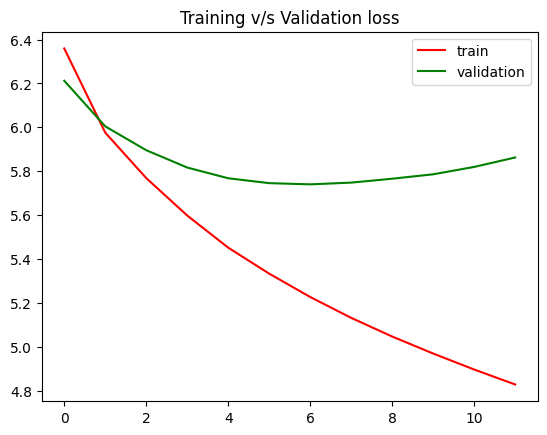

In [17]:
# Plotting training v/s validation loss

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'green', label = 'validation')
plt.title('Training v/s Validation loss')
plt.legend()
plt.show()

In [18]:
best_weights = model.get_weights()

In [19]:
for w in best_weights:
    print(w.shape)

(8214, 100)
(100, 256)
(64, 256)
(256,)
(64, 8214)
(8214,)


In [20]:
best_epoch = history.history['val_loss'].index(min(history.history['val_loss']))
print("Best epoch:", best_epoch+1)

Best epoch: 7


In [21]:
perplexity = np.exp(5.8623)
perplexity

np.float64(351.53173792813953)